# **Dynamic Naural Networks**

### **Preparación del entorno**

In [ ]:
"""
Dynamic Neural Network con Early Exiting - Disney/Cartoon Characters
Implementación adaptada de "Dynamic Neural Networks: A Survey" (Han et al., 2021)

Tipo: Sample-wise Dynamic Network con Early Exiting
Aplicación: Clasificación de personajes icónicos de Disney/Cartoon

Este código implementa una red dinámica que:
1. Entrena múltiples clasificadores intermedios
2. Durante inferencia, sale temprano cuando alcanza alta confianza
3. Personajes icónicos (Mickey, Olaf) → Exit 1
4. Personajes similares o menos conocidos → Exit 3
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torch.nn.functional import softmax
import time
from PIL import Image
import os
from pathlib import Path
import random
from google.colab import drive

### **Configuración y Constantes**


In [ ]:

drive.mount('/content/drive')

# Configuración de personajes (clases reales del dataset)
CHARACTERS = ['donald', 'mickey', 'minion', 'olaf', 'pooh', 'pumba']

CHARACTER_EMOJIS = {
    'donald': '🦆',
    'mickey': '🐭',
    'minion': '👾',
    'olaf': '⛄',
    'pooh': '🐻',
    'pumba': '🐗'
}

CHARACTER_INFO = {
    'donald': 'Donald Duck - Clásico Disney',
    'mickey': 'Mickey Mouse - Clásico Disney',
    'minion': 'Minion - Despicable Me (2010)',
    'olaf': 'Olaf - Frozen (2013)',
    'pooh': 'Winnie the Pooh - Clásico Disney',
    'pumba': 'Pumba - The Lion King (1994)'
}

# Hiperparámetros
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
ENTROPY_THRESHOLD = 0.35  # Umbral para early exiting

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🏰 Usando dispositivo: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🏰 Usando dispositivo: cuda


### **Funciones para preparar el Dataset**`

In [ ]:
def verify_dataset():
    """
    Verifica que el dataset exista y muestra información
    """
    print("\n" + "="*70)
    print("📥 VERIFICANDO DATASET DE PERSONAJES")
    print("="*70)

    data_dir = Path('/content/drive/MyDrive/IA2/PresentacionDNN/disney_characters')
    train_dir = data_dir / 'train'
    test_dir = data_dir / 'test'

    if not train_dir.exists() or not test_dir.exists():
        print("\n❌ ERROR: No se encontró el dataset")
        raise FileNotFoundError("Dataset no encontrado. Sigue las instrucciones anteriores.")

    # Contar imágenes por clase
    print("\n✓ Dataset encontrado!")
    print("\n📊 Resumen del Dataset:")
    print("-" * 70)

    total_train = 0
    total_test = 0

    for character in CHARACTERS:
        train_path = train_dir / character
        test_path = test_dir / character

        if train_path.exists():
            train_imgs = len(list(train_path.glob('*.jpg')) + list(train_path.glob('*.png')))
            total_train += train_imgs
        else:
            train_imgs = 0

        if test_path.exists():
            test_imgs = len(list(test_path.glob('*.jpg')) + list(test_path.glob('*.png')))
            total_test += test_imgs
        else:
            test_imgs = 0

        emoji = CHARACTER_EMOJIS[character]
        print(f"  {emoji} {character.capitalize():12} - Train: {train_imgs:4} | Test: {test_imgs:4}")

    print("-" * 70)
    print(f"  {'TOTAL':14} - Train: {total_train:4} | Test: {total_test:4}")
    print("="*70)

    return data_dir


def visualize_dataset_samples(data_dir, num_samples=4):
    """
    Visualiza muestras aleatorias del dataset antes del entrenamiento
    """
    print("\n" + "="*70)
    print("🎨 VISUALIZANDO MUESTRAS DEL DATASET")
    print("="*70)

    train_dir = data_dir / 'train'

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('🎨 Muestras del Dataset - Personajes Cartoon\n(Antes del Entrenamiento)',
                 fontsize=16, fontweight='bold', y=0.98)

    plot_idx = 1

    for character in CHARACTERS:
        char_dir = train_dir / character

        if not char_dir.exists():
            continue

        # Obtener todas las imágenes del personaje
        images = list(char_dir.glob('*.jpg')) + list(char_dir.glob('*.png'))

        if len(images) == 0:
            continue

        # Seleccionar muestras aleatorias
        sample_images = random.sample(images, min(num_samples, len(images)))

        for img_path in sample_images:
            ax = plt.subplot(len(CHARACTERS), num_samples, plot_idx)

            try:
                img = Image.open(img_path).convert('RGB')
                ax.imshow(img)
                ax.axis('off')

                emoji = CHARACTER_EMOJIS[character]
                if plot_idx % num_samples == 1:  # Primera columna
                    ax.set_ylabel(f"{emoji} {character.capitalize()}",
                                fontsize=12, fontweight='bold', rotation=0,
                                labelpad=60, ha='right', va='center')

            except Exception as e:
                print(f"Error cargando {img_path}: {e}")

            plot_idx += 1

    plt.tight_layout()
    plt.show()

    print("✓ Visualización completada\n")


### **Dataset personalizado**

In [ ]:
class CartoonCharactersDataset(Dataset):
    """Dataset personalizado para personajes cartoon"""

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        # Usar las clases correctas del dataset
        self.classes = CHARACTERS
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Cargar todas las imágenes
        for class_name in self.classes:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                continue

            for img_path in list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg')):
                self.images.append(img_path)
                self.labels.append(self.class_to_idx[class_name])

        print(f"  Cargadas {len(self.images)} imágenes de {self.root_dir.name}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Retornar imagen en blanco si falla
            return torch.zeros(3, 224, 224), label



### **Arquitectura de la Red Dinámica**


In [ ]:

class CartoonEarlyExitDNN(nn.Module):
    """
    Red Neuronal Dinámica para Clasificación de Personajes Cartoon

    Arquitectura optimizada para reconocer personajes icónicos:
    - Exit 1: Características muy distintivas (orejas de Mickey, forma de Olaf)
    - Exit 2: Patrones de color y forma (amarillo de Minion, naranja de Pumba)
    - Exit 3: Detalles finos para personajes similares o ángulos difíciles
    """

    def __init__(self, num_classes=6):
        super(CartoonEarlyExitDNN, self).__init__()

        # ===== EXIT POINT 1 (Shallow - Características icónicas) =====
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),  # Captura formas grandes
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),  # 224 → 56
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 → 28
            nn.Dropout2d(0.2)
        )
        self.exit1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

        # ===== EXIT POINT 2 (Medium - Patrones de color y textura) =====
        self.block2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28 → 14
            nn.Dropout2d(0.3)
        )
        self.exit2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )

        # ===== EXIT POINT 3 (Deep - Análisis detallado) =====
        self.block3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14 → 7
            nn.Dropout2d(0.3)
        )
        self.exit3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x1 = self.block1(x)
        out1 = self.exit1(x1)

        x2 = self.block2(x1)
        out2 = self.exit2(x2)

        x3 = self.block3(x2)
        out3 = self.exit3(x3)

        return out1, out2, out3

    def compute_entropy(self, logits):
        """Calcula entropía de Shannon para medir confianza"""
        probs = softmax(logits, dim=1)
        log_probs = torch.log(probs + 1e-10)
        entropy = -torch.sum(probs * log_probs, dim=1)
        return entropy

    def dynamic_inference(self, x, threshold=0.35):
        """
        Inferencia DINÁMICA con Early Exiting

        - Personajes icónicos (Mickey con orejas, Olaf muñeco de nieve) → Exit 1
        - Personajes con colores únicos (Minion amarillo, Pumba naranja) → Exit 2
        - Personajes similares o ángulos difíciles → Exit 3
        """
        # Exit 1 - Características icónicas
        x1 = self.block1(x)
        out1 = self.exit1(x1)
        entropy1 = self.compute_entropy(out1).item()

        if entropy1 < threshold:
            prob = softmax(out1, dim=1)
            confidence = prob.max().item()
            return out1, 1, confidence

        # Exit 2 - Patrones de color/textura
        x2 = self.block2(x1)
        out2 = self.exit2(x2)
        entropy2 = self.compute_entropy(out2).item()

        if entropy2 < threshold:
            prob = softmax(out2, dim=1)
            confidence = prob.max().item()
            return out2, 2, confidence

        # Exit 3 - Análisis completo
        x3 = self.block3(x2)
        out3 = self.exit3(x3)
        prob = softmax(out3, dim=1)
        confidence = prob.max().item()
        return out3, 3, confidence


### **Preparar y Visualizar Dataset**


📥 VERIFICANDO DATASET DE PERSONAJES

✓ Dataset encontrado!

📊 Resumen del Dataset:
----------------------------------------------------------------------
  🦆 Donald       - Train:  463 | Test:   70
  🐭 Mickey       - Train:  386 | Test:   87
  👾 Minion       - Train:  633 | Test:   72
  ⛄ Olaf         - Train:  527 | Test:   68
  🐻 Pooh         - Train:  579 | Test:   63
  🐗 Pumba        - Train:  568 | Test:   52
----------------------------------------------------------------------
  TOTAL          - Train: 3156 | Test:  412

🎨 VISUALIZANDO MUESTRAS DEL DATASET


/tmp/ipython-input-3855489576.py:128: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


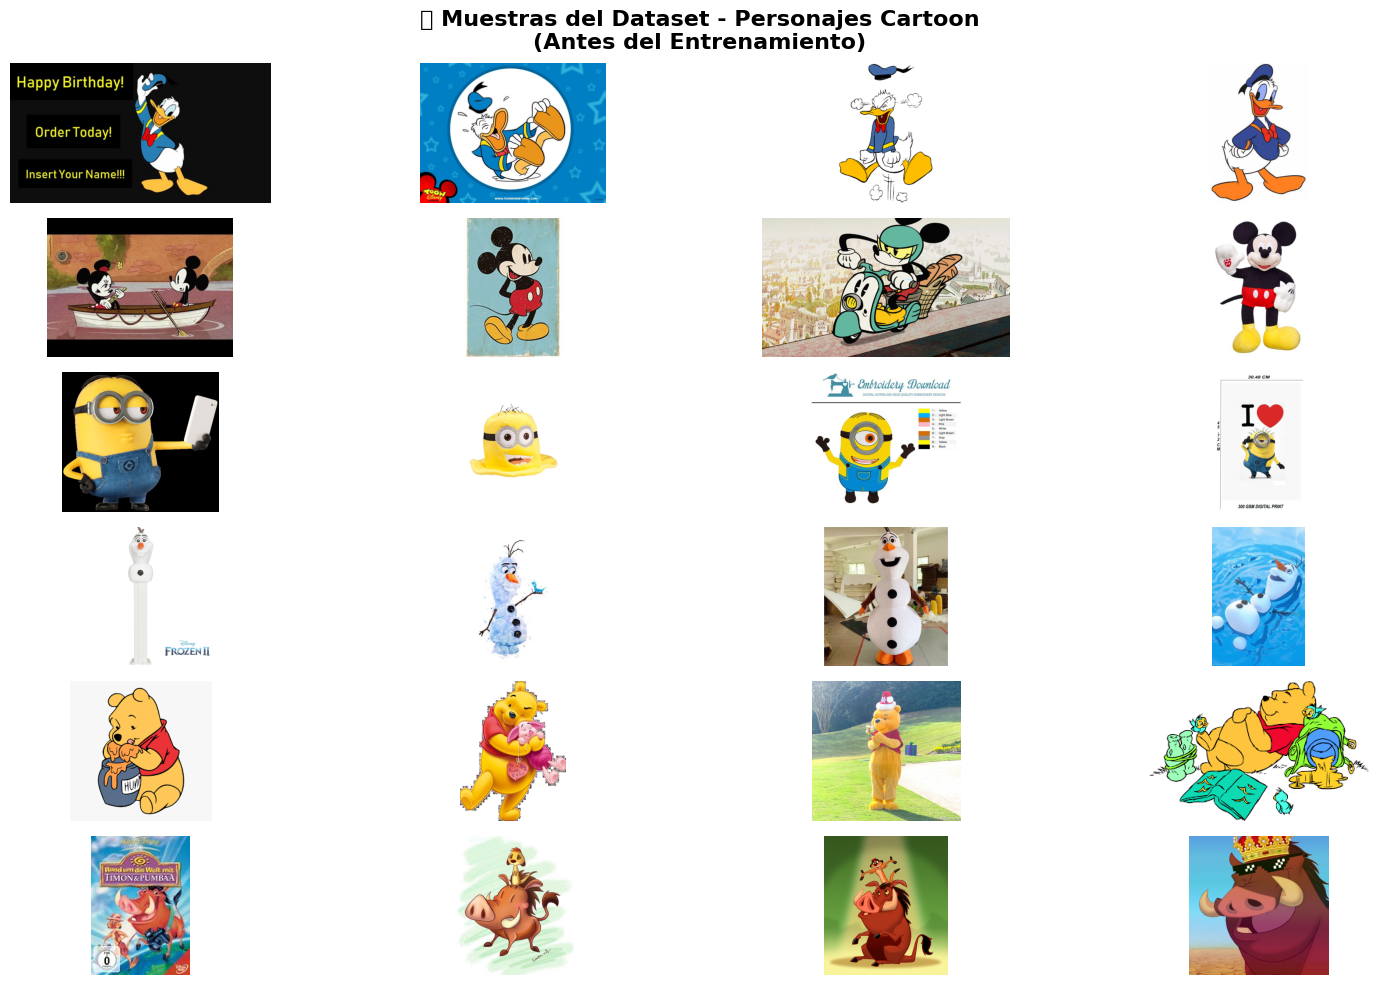

✓ Visualización completada


🎨 CARGANDO DATASET PARA ENTRENAMIENTO
  Cargadas 3522 imágenes de train
  Cargadas 433 imágenes de test

✓ Datasets cargados exitosamente!
  Clases detectadas: ['donald', 'mickey', 'minion', 'olaf', 'pooh', 'pumba']


In [ ]:
data_dir = verify_dataset()

#Visualizar muestras del dataset
visualize_dataset_samples(data_dir, num_samples=4)

print("\n" + "="*70)
print("🎨 CARGANDO DATASET PARA ENTRENAMIENTO")
print("="*70)

# Transformaciones
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargar datasets
trainset = CartoonCharactersDataset(data_dir / 'train', transform=transform_train)
testset = CartoonCharactersDataset(data_dir / 'test', transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader_single = DataLoader(testset, batch_size=1, shuffle=False, num_workers=2)

print(f"\n✓ Datasets cargados exitosamente!")
print(f"  Clases detectadas: {trainset.classes}")
print("="*70)




### **Entrenamiento**

In [ ]:
print("\n" + "="*70)
print("🚀 INICIANDO ENTRENAMIENTO")
print("="*70)

# Configuración del modelo
model = CartoonEarlyExitDNN(num_classes=len(trainset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=12, gamma=0.5)

exit_weights = [0.2, 0.3, 0.5]
train_losses = []
train_accuracies = []

# Entrenamiento
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        out1, out2, out3 = model(images)

        loss1 = criterion(out1, labels)
        loss2 = criterion(out2, labels)
        loss3 = criterion(out3, labels)

        loss = (exit_weights[0] * loss1 +
                exit_weights[1] * loss2 +
                exit_weights[2] * loss3)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(out3.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch [{batch_idx+1}/{len(trainloader)}] - "
                  f"Loss: {running_loss/(batch_idx+1):.4f}")

    epoch_loss = running_loss / len(trainloader)
    epoch_accuracy = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    scheduler.step()

    print(f"\n{'='*70}")
    print(f"Época [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Pérdida: {epoch_loss:.4f}")
    print(f"  Precisión: {epoch_accuracy:.2f}%")
    print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
    print(f"{'='*70}\n")

print("✓ Entrenamiento completado!\n")



🚀 INICIANDO ENTRENAMIENTO


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Batch [10/56] - Loss: 2.0082
  Batch [20/56] - Loss: 1.6922
  Batch [30/56] - Loss: 1.5023
Error loading /content/drive/MyDrive/IA2/PresentacionDNN/disney_characters/train/donald/history-donald-duck-personality.jpg: image file is truncated (5 bytes not processed)
  Batch [40/56] - Loss: 1.4136
  Batch [50/56] - Loss: 1.3364


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))



Época [1/30]
  Pérdida: 1.3048
  Precisión: 51.42%
  Learning Rate: 0.001000



...

  Batch [10/56] - Loss: 0.2769


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Batch [20/56] - Loss: 0.2808
  Batch [30/56] - Loss: 0.2907
  Batch [40/56] - Loss: 0.2885
  Batch [50/56] - Loss: 0.2993

Época [29/30]
  Pérdida: 0.3005
  Precisión: 92.08%
  Learning Rate: 0.000250



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Batch [10/56] - Loss: 0.2874
Error loading /content/drive/MyDrive/IA2/PresentacionDNN/disney_characters/train/donald/history-donald-duck-personality.jpg: image file is truncated (5 bytes not processed)
  Batch [20/56] - Loss: 0.3103
  Batch [30/56] - Loss: 0.3023
  Batch [40/56] - Loss: 0.3013
  Batch [50/56] - Loss: 0.2973

Época [30/30]
  Pérdida: 0.3076
  Precisión: 92.14%
  Learning Rate: 0.000250

✓ Entrenamiento completado!



### **Guardar Modelo**

In [ ]:
print("\n" + "="*70)
print("💾 GUARDANDO MODELO ENTRENADO")
print("="*70)

# Crear carpeta para modelos si no existe
models_dir = Path('./models')
models_dir.mkdir(exist_ok=True)

# Nombre del archivo del modelo
model_filename = 'cartoon_early_exit_model.pth'
model_path = models_dir / model_filename

# Guardar el modelo completo (arquitectura + pesos + optimizador)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'epoch': NUM_EPOCHS,
    'train_losses': train_losses,
    'train_accuracies': train_accuracies,
    'classes': trainset.classes,
    'num_classes': len(trainset.classes),
    'best_accuracy': train_accuracies[-1] if train_accuracies else 0,
    'entropy_threshold': ENTROPY_THRESHOLD
}

torch.save(checkpoint, model_path)
print(f"✓ Modelo guardado en: {model_path}")
print(f"  Tamaño del archivo: {model_path.stat().st_size / (1024*1024):.2f} MB")

# Guardar también solo los pesos (más ligero)
weights_filename = 'cartoon_early_exit_weights.pth'
weights_path = models_dir / weights_filename
torch.save(model.state_dict(), weights_path)
print(f"✓ Pesos guardados en: {weights_path}")
print(f"  Tamaño del archivo: {weights_path.stat().st_size / (1024*1024):.2f} MB")

print("="*70)


💾 GUARDANDO MODELO ENTRENADO
✓ Modelo guardado en: models/cartoon_early_exit_model.pth
  Tamaño del archivo: 138.99 MB
✓ Pesos guardados en: models/cartoon_early_exit_weights.pth
  Tamaño del archivo: 46.34 MB


### **Descargar el Dataset**

In [ ]:
from google.colab import files
files.download('models/cartoon_early_exit_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Evaluación Estandar**





In [ ]:
print("="*70)
print("📊 EVALUACIÓN ESTÁNDAR (Sin dinamismo)")
print("="*70)

model.eval()
correct1, correct2, correct3 = 0, 0, 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        out1, out2, out3 = model(images)

        _, pred1 = torch.max(out1.data, 1)
        _, pred2 = torch.max(out2.data, 1)
        _, pred3 = torch.max(out3.data, 1)

        total += labels.size(0)
        correct1 += (pred1 == labels).sum().item()
        correct2 += (pred2 == labels).sum().item()
        correct3 += (pred3 == labels).sum().item()

acc1 = 100 * correct1 / total
acc2 = 100 * correct2 / total
acc3 = 100 * correct3 / total

print(f"Precisión Exit 1 (Características Icónicas): {acc1:.2f}%")
print(f"Precisión Exit 2 (Patrones Color/Forma):     {acc2:.2f}%")
print(f"Precisión Exit 3 (Análisis Completo):        {acc3:.2f}%")


📊 EVALUACIÓN ESTÁNDAR (Sin dinamismo)
Precisión Exit 1 (Características Icónicas): 94.69%
Precisión Exit 2 (Patrones Color/Forma):     97.23%
Precisión Exit 3 (Análisis Completo):        97.23%


### **Evaluación Dinámica**

In [ ]:

print("\n" + "="*70)
print("✨ EVALUACIÓN DINÁMICA (Con Early Exiting)")
print("="*70)

model.eval()
exit_counts = {1: 0, 2: 0, 3: 0}
correct_dynamic = 0
total_dynamic = 0
inference_times = []
sample_data = []

num_samples = min(200, len(testset))
random_indices = np.random.choice(num_samples, size=min(24, num_samples), replace=False)
random_indices_set = set(random_indices)

with torch.no_grad():
    for idx, (image, label) in enumerate(testloader_single):
        if idx >= num_samples:
            break

        image = image.to(device)
        label_val = label.item()

        start_time = time.time()
        prediction, exit_point, confidence = model.dynamic_inference(
            image, threshold=ENTROPY_THRESHOLD
        )
        inference_time = time.time() - start_time

        predicted_label = prediction.argmax().item()
        is_correct = predicted_label == label_val

        exit_counts[exit_point] += 1
        correct_dynamic += int(is_correct)
        total_dynamic += 1
        inference_times.append(inference_time)

        if idx in random_indices_set:
            img = image.squeeze(0).cpu().numpy()
            img = img * np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
            img = img + np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
            img = np.transpose(img, (1, 2, 0))
            img = np.clip(img, 0, 1)

            sample_data.append({
                'image': img,
                'true_label': label_val,
                'pred_label': predicted_label,
                'correct': is_correct,
                'exit_point': exit_point,
                'confidence': confidence
            })

acc_dynamic = 100 * correct_dynamic / total_dynamic
avg_inference_time = np.mean(inference_times) * 1000

print(f"\nResultados (threshold={ENTROPY_THRESHOLD}):")
print(f"  Precisión: {acc_dynamic:.2f}%")
print(f"  Tiempo promedio: {avg_inference_time:.4f} ms")
print(f"\nDistribución de Exit Points:")
print(f"  Exit 1: {exit_counts[1]} personajes ({exit_counts[1]/total_dynamic*100:.1f}%)")
print(f"  Exit 2: {exit_counts[2]} personajes ({exit_counts[2]/total_dynamic*100:.1f}%)")
print(f"  Exit 3: {exit_counts[3]} personajes ({exit_counts[3]/total_dynamic*100:.1f}%)")

avg_depth = (exit_counts[1] * 1 + exit_counts[2] * 2 + exit_counts[3] * 3) / total_dynamic
print(f"  Profundidad promedio: {avg_depth:.2f}")
print(f"  Ahorro computacional: {(1 - avg_depth/3)*100:.1f}%")



✨ EVALUACIÓN DINÁMICA (Con Early Exiting)

Resultados (threshold=0.35):
  Precisión: 96.50%
  Tiempo promedio: 2.7932 ms

Distribución de Exit Points:
  Exit 1: 146 personajes (73.0%)
  Exit 2: 26 personajes (13.0%)
  Exit 3: 28 personajes (14.0%)
  Profundidad promedio: 1.41
  Ahorro computacional: 53.0%


### **Gráficas**

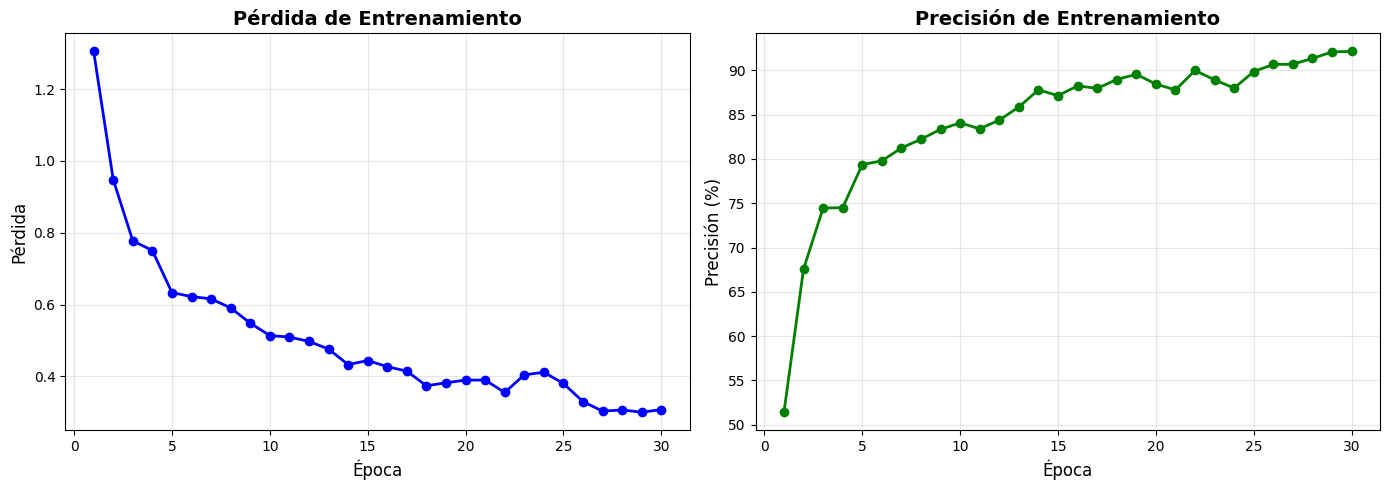

/tmp/ipython-input-2303576733.py:45: UserWarning: Glyph 129414 (\N{DUCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2303576733.py:45: UserWarning: Glyph 128126 (\N{ALIEN MONSTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2303576733.py:45: UserWarning: Glyph 127984 (\N{EUROPEAN CASTLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129414 (\N{DUCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128126 (\N{ALIEN MONSTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127984 (\N{EUROPEAN CASTLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


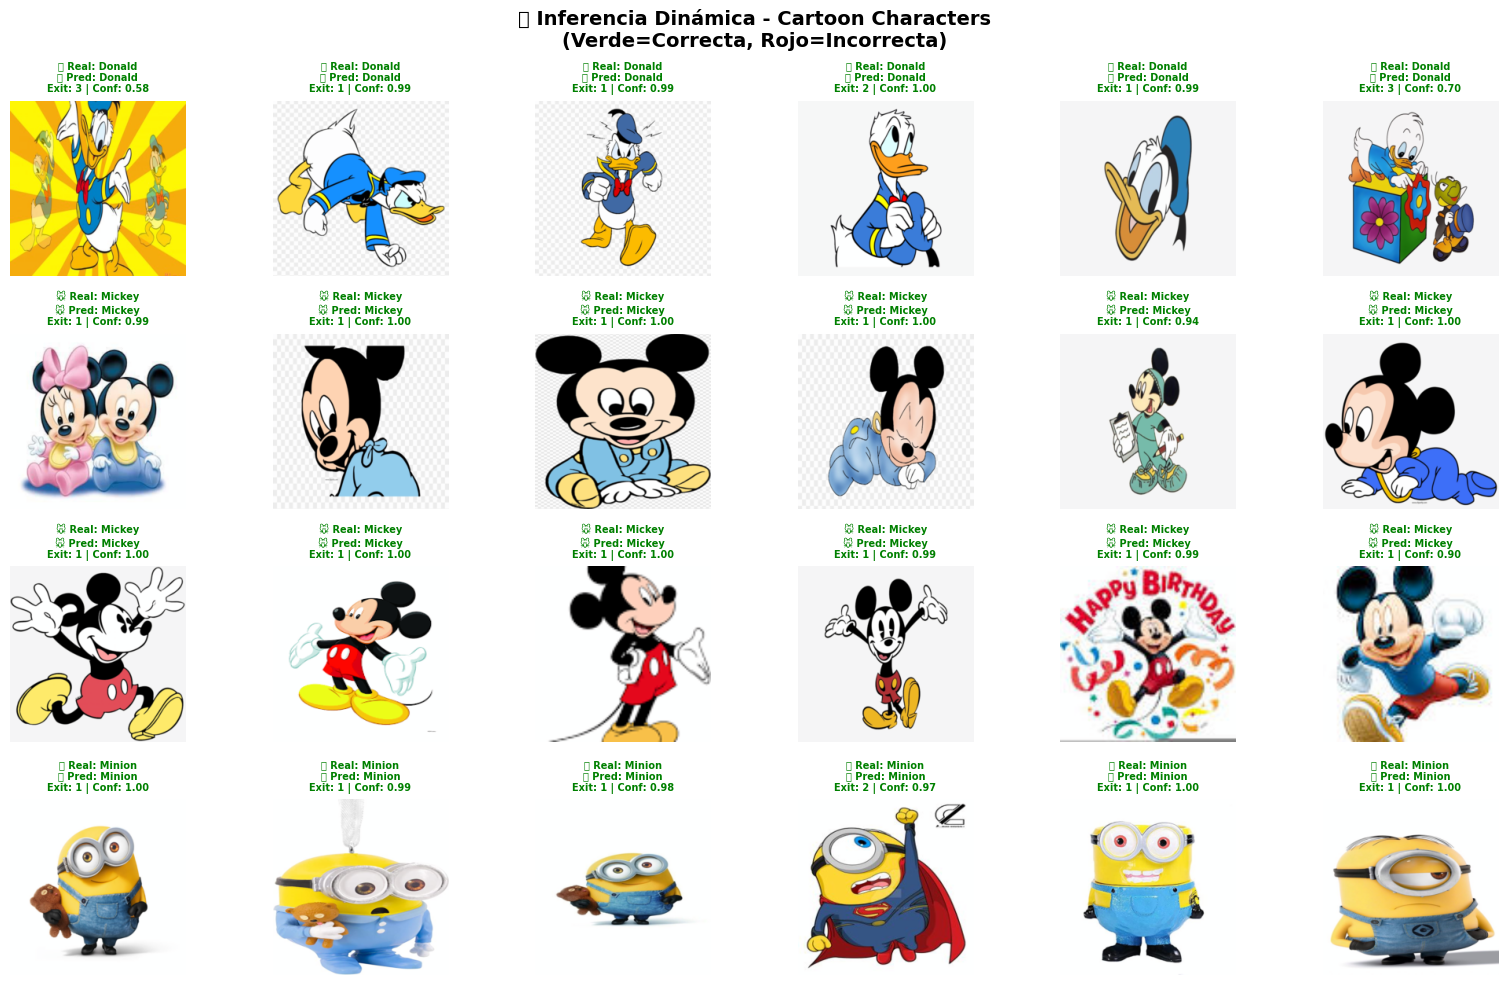

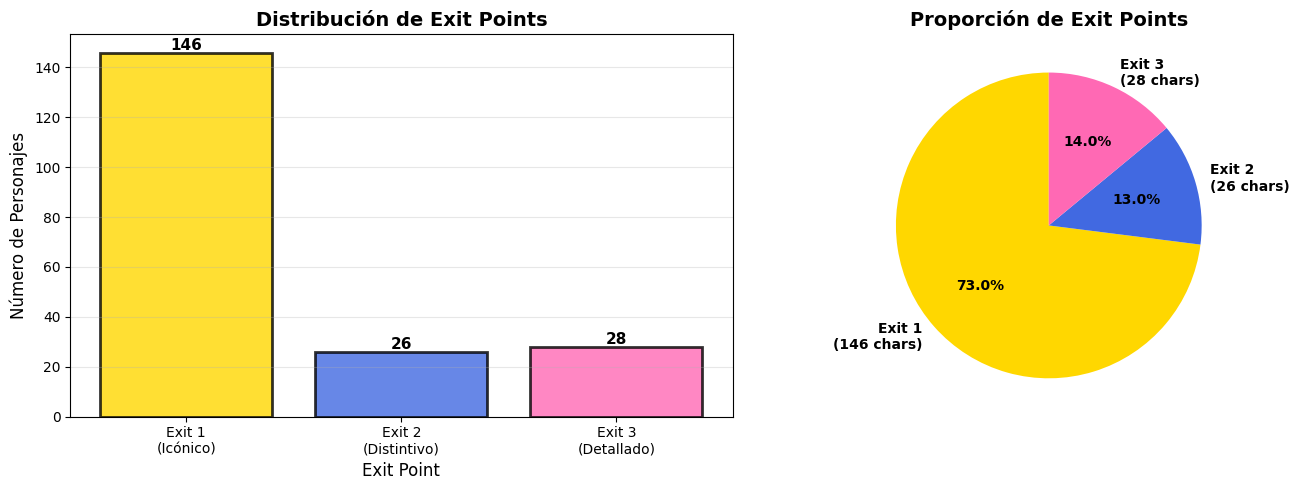


✅ ANÁLISIS COMPLETADO


In [ ]:
# 1. Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-', linewidth=2, marker='o')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Pérdida', fontsize=12)
ax1.set_title('Pérdida de Entrenamiento', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, NUM_EPOCHS+1), train_accuracies, 'g-', linewidth=2, marker='o')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Precisión (%)', fontsize=12)
ax2.set_title('Precisión de Entrenamiento', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Predicciones visuales
fig = plt.figure(figsize=(16, 10))

for idx, data in enumerate(sample_data):
    ax = plt.subplot(4, 6, idx + 1)
    ax.imshow(data['image'])
    ax.axis('off')

    color = 'green' if data['correct'] else 'red'
    true_char = trainset.classes[data['true_label']]
    pred_char = trainset.classes[data['pred_label']]

    true_emoji = CHARACTER_EMOJIS.get(true_char, '🎭')
    pred_emoji = CHARACTER_EMOJIS.get(pred_char, '🎭')

    title = (f"{true_emoji} Real: {true_char.capitalize()}\n"
             f"{pred_emoji} Pred: {pred_char.capitalize()}\n"
             f"Exit: {data['exit_point']} | Conf: {data['confidence']:.2f}")
    ax.set_title(title, fontsize=7, color=color, fontweight='bold')

plt.suptitle('🏰 Inferencia Dinámica - Cartoon Characters\n(Verde=Correcta, Rojo=Incorrecta)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Distribución de exit points
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

exits = list(exit_counts.keys())
counts = list(exit_counts.values())
colors = ['#FFD700', '#4169E1', '#FF69B4']

ax1.bar(exits, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_xlabel('Exit Point', fontsize=12)
ax1.set_ylabel('Número de Personajes', fontsize=12)
ax1.set_title('Distribución de Exit Points', fontsize=14, fontweight='bold')
ax1.set_xticks(exits)
ax1.set_xticklabels(['Exit 1\n(Icónico)', 'Exit 2\n(Distintivo)', 'Exit 3\n(Detallado)'])
ax1.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(counts):
    ax1.text(exits[i], v + 1, str(v), ha='center', fontweight='bold', fontsize=11)

ax2.pie(counts, labels=[f'Exit {i}\n({c} chars)' for i, c in zip(exits, counts)],
        colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontweight': 'bold', 'fontsize': 10})
ax2.set_title('Proporción de Exit Points', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)
